In [1887]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
import xgboost as xgb

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

from scipy.optimize import curve_fit

import preprocessor as pp

In [1894]:
import importlib
importlib.reload(pp)

<module 'preprocessor' from '/Users/victorli/Desktop/vsc/Programming with Data/DS2500/Battery-RUL-Analysis/preprocessor.py'>

## Preprocessing and Splitting

In [1161]:
path = 'cleaned_dataset/'

In [1163]:
df = pp.read_clean_file(path)
df

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,2010-07-21 15:00:35.093000,4,B0047,0,1,00001.csv,1.674305,NaN,NaN
1,impedance,2010-07-21 16:53:45.968000,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,2010-07-21 17:25:40.670999,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,2010-07-21 20:31:05.000000,24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,2010-07-21 21:02:56.984000,4,B0047,4,5,00005.csv,1.524366,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
7560,impedance,2010-09-30 07:36:45.045999,24,B0055,247,7561,07561.csv,NaN,0.0968087979207628,0.15489738203707232
7561,discharge,2010-09-30 08:08:36.328000,4,B0055,248,7562,07562.csv,1.020138,NaN,NaN
7562,charge,2010-09-30 08:48:54.250000,4,B0055,249,7563,07563.csv,NaN,NaN,NaN
7563,discharge,2010-09-30 11:50:17.687000,4,B0055,250,7564,07564.csv,0.990759,NaN,NaN


In [1408]:
BATTERIES = sorted(df['battery_id'].value_counts().index.tolist())
#bad_batteries = ['B0038', 'B0039', 'B0040', 'B0041', 'B0052'] #manually found, batteries 38-41 have rising capacities
#while battery 52 only has 4 valid discharge datapoints
#BATTERIES = [b for b in BATTERIES if b not in bad_batteries]
print(len(BATTERIES))



34


In [1896]:
bat_tr, bat_val = train_test_split(BATTERIES,test_size=0.2,random_state=21)
print(bat_tr)
print(bat_val)

df_tr = df[df['battery_id'].isin(bat_tr)]
df_val = df[df['battery_id'].isin(bat_val)]
dis_tr = pp.get_discharges_phyiscs(path, df_tr)
dis_val = pp.get_discharges_phyiscs(path, df_val)
dis_tr = pp.merge_impedance_with_discharges(df_tr, dis_tr, path)
dis_val = pp.merge_impedance_with_discharges(df_val, dis_val, path)


['B0055', 'B0026', 'B0042', 'B0045', 'B0028', 'B0050', 'B0032', 'B0041', 'B0027', 'B0053', 'B0044', 'B0051', 'B0056', 'B0033', 'B0036', 'B0029', 'B0031', 'B0040', 'B0007', 'B0018', 'B0054', 'B0052', 'B0039', 'B0025', 'B0047', 'B0038', 'B0030']
['B0006', 'B0043', 'B0049', 'B0005', 'B0034', 'B0048', 'B0046']


In [1898]:
dis_val

,start_time,ambient_temperature,battery_id,uid,filename,Capacity,cycle_number,SOH,EOL_cycle,RUL,...,mean_dvdt,capacity_Ah,capacity_ratio,voltage_drop,Battery_impedance_real_mean,Battery_impedance_mag_mean,Rectified_impedance_real_mean,Rectified_impedance_phase_mean,Re,Rct
0,2008-04-02 15:25:41.593000,24,B0005,5122,05122.csv,1.856487,1,0.928244,168,167,...,-0.000249,1.862203,1.003079,0.914322,0.171894,0.208950,0.059184,-0.017650,0.044669,0.069456
1,2008-04-02 15:25:41.593000,24,B0006,4506,04506.csv,2.035338,1,1.017669,168,167,...,-0.000465,2.046703,1.005584,1.704032,0.173923,0.190841,0.071337,-0.012372,0.061234,0.078542
2,2008-04-02 19:43:48.405999,24,B0005,5124,05124.csv,1.846327,2,0.923164,168,166,...,-0.000244,1.852078,1.003115,0.889528,0.171894,0.208950,0.059184,-0.017650,0.044669,0.069456
3,2008-04-02 19:43:48.405999,24,B0006,4508,04508.csv,2.025140,2,1.012570,168,166,...,-0.000502,2.036566,1.005642,1.825763,0.173923,0.190841,0.071337,-0.012372,0.061234,0.078542
4,2008-04-03 00:01:06.687000,24,B0005,5126,05126.csv,1.835349,3,0.917675,168,165,...,-0.000237,1.841049,1.003105,0.860736,0.171894,0.208950,0.059184,-0.017650,0.044669,0.069456
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
801,2010-08-29 03:37:19.780999,4,B0049,4307,04307.csv,0.734939,21,0.367469,25,4,...,-0.001181,0.998429,1.358520,2.169008,0.222359,0.241782,0.090842,-0.071996,0.069976,0.069976
802,2010-08-29 07:09:53.920999,4,B0049,4309,04309.csv,0.736676,22,0.368338,25,3,...,-0.001323,0.905054,1.228565,2.190418,0.222359,0.241782,0.090842,-0.071996,0.069976,0.069976
803,2010-08-29 10:39:41.561999,4,B0049,4311,04311.csv,0.709395,23,0.354697,25,2,...,-0.001244,0.963205,1.357784,2.188363,0.222359,0.241782,0.090842,-0.071996,0.069976,0.069976
804,2010-08-29 14:11:14.561999,4,B0049,4313,04313.csv,0.718647,24,0.359323,25,1,...,-0.001338,0.894507,1.244710,2.194260,0.222359,0.241782,0.090842,-0.071996,0.069976,0.069976


In [1867]:
pp.impedance_features(path, '00002.csv')

{'Battery_impedance_real_mean': 0.20667752523246005,
 'Battery_impedance_mag_mean': 0.21392855186944962,
 'Rectified_impedance_real_mean': 0.08360003221854975,
 'Rectified_impedance_phase_mean': -0.07934092705559784}

## Predicting Capacity - val

In [1652]:
features = ['ambient_temperature', 
            'cycle_number',
            'mean_voltage',
            'max_voltage',
            'min_voltage',
            'mean_current',
            'max_current',
            'mean_temperature',
            'max_temperature',
            'discharge_time']
target = 'Capacity'
disx_tr = dis_tr[features].values
disy_tr = dis_tr[target].values
disx_val = dis_val[features].values
disy_val = dis_val[target].values

In [1654]:
features_physics = ['ambient_temperature', 
            'cycle_number',
            'mean_voltage',
            'max_voltage',
            'min_voltage',
            'mean_current',
            'max_current',
            'mean_temperature',
            'max_temperature',
            'discharge_time',
            'r_internal', 
            'mean_dvdt', 
            'voltage_drop',
            'Rectified_impedance_phase_mean']
target = 'Capacity'

disx_tr = dis_tr[features_physics].values
disy_tr = dis_tr[target].values
disx_val = dis_val[features_physics].values
disy_val = dis_val[target].values

In [1656]:
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    random_state=21
)
rf_model.fit(disx_tr, disy_tr)

pred_rf = rf_model.predict(disx_val)

print("RF MAE:", mean_absolute_error(disy_val, pred_rf))
print("RF MSE:", mean_squared_error(disy_val, pred_rf))
print("RF R2:", r2_score(disy_val, pred_rf))

dis_val["pred_rf_cap"]  = pred_rf
'''
trained on 'features':
RF MAE: 0.057776649944968075
RF MSE: 0.006399883004647191
RF R2: 0.9574231322107574

trained on 'features_physics':
RF MAE: 0.005009148422786603
RF MSE: 0.00010839267808735419
RF R2: 0.9993033882679051
'''

RF MAE: 0.0529499392544348
RF MSE: 0.004948997050852791
RF R2: 0.9670755241977854


"\ntrained on 'features':\nRF MAE: 0.057776649944968075\nRF MSE: 0.006399883004647191\nRF R2: 0.9574231322107574\n\ntrained on 'features_physics':\nRF MAE: 0.005009148422786603\nRF MSE: 0.00010839267808735419\nRF R2: 0.9993033882679051\n"

In [1657]:
xgb_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.02,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=21
)

xgb_model.fit(disx_tr, disy_tr)

pred_xgb = xgb_model.predict(disx_val)

print("XGB MAE:", mean_absolute_error(disy_val, pred_xgb))
print("XGB RMSE:", np.sqrt(mean_squared_error(disy_val, pred_xgb)))
print("XGB R2:", r2_score(disy_val, pred_xgb))

dis_val["pred_xgb_cap"]  = pred_xgb
'''
trained on 'features':
XGB MAE: 0.06543340493941216
XGB RMSE: 0.09152594937403981
XGB R2: 0.9442698568019331

trained on 'features_physics':
XGB MAE: 0.0026461589217051545
XGB RMSE: 0.003459339839617803
XGB R2: 0.9999230909769515
'''

XGB MAE: 0.05138795278489159
XGB RMSE: 0.06300273915495941
XGB R2: 0.9735929105021612


"\ntrained on 'features':\nXGB MAE: 0.06543340493941216\nXGB RMSE: 0.09152594937403981\nXGB R2: 0.9442698568019331\n\ntrained on 'features_physics':\nXGB MAE: 0.0026461589217051545\nXGB RMSE: 0.003459339839617803\nXGB R2: 0.9999230909769515\n"

In [1720]:
knn_model = KNeighborsRegressor(n_neighbors=3) 

knn_model.fit(disx_tr, disy_tr)

pred_knn = knn_model.predict(disx_val)

print("KNN MAE:", mean_absolute_error(disy_val, pred_knn))
print("KNN RMSE:", np.sqrt(mean_squared_error(disy_val, pred_knn)))
print("KNN R2:", r2_score(disy_val, pred_knn))

dis_val["pred_knn_cap"]  = pred_knn

KNN MAE: 0.12413070821810084
KNN RMSE: 0.16806089646352596
KNN R2: 0.8120964324177806


In [1662]:
lin_model = LinearRegression()
lin_model.fit(disx_tr, disy_tr)

pred_lin = lin_model.predict(disx_val)

print("LIN MAE:", mean_absolute_error(disy_val, pred_lin))
print("LIN RMSE:", np.sqrt(mean_squared_error(disy_val, pred_lin)))
print("LIN R2:", r2_score(disy_val, pred_lin))

dis_val["pred_lin_cap"]  = pred_lin

LIN MAE: 0.13797695340787738
LIN RMSE: 0.1867045392730641
LIN R2: 0.7680942974807774


['B0006', 'B0043', 'B0049', 'B0005', 'B0034', 'B0048', 'B0046']


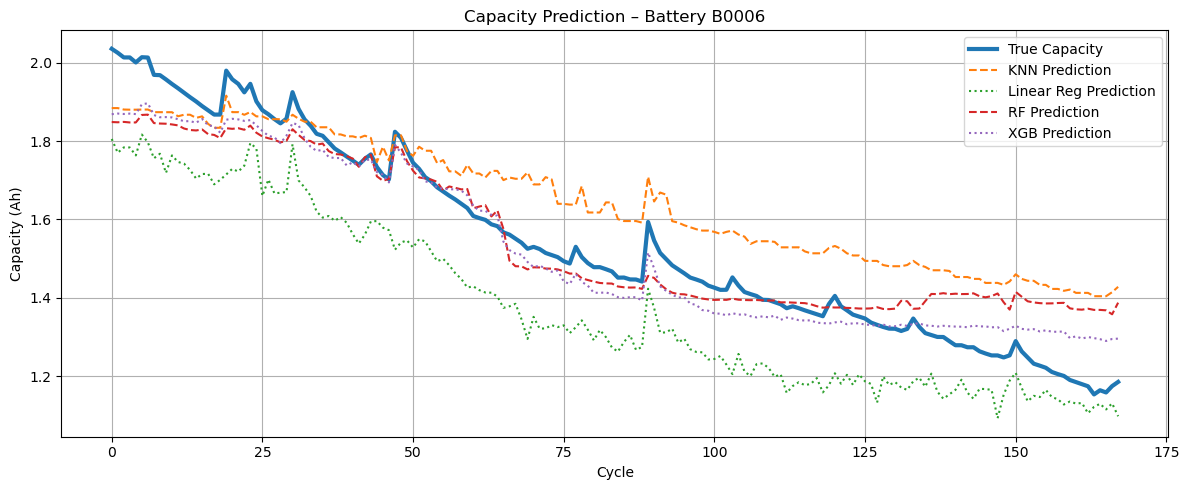

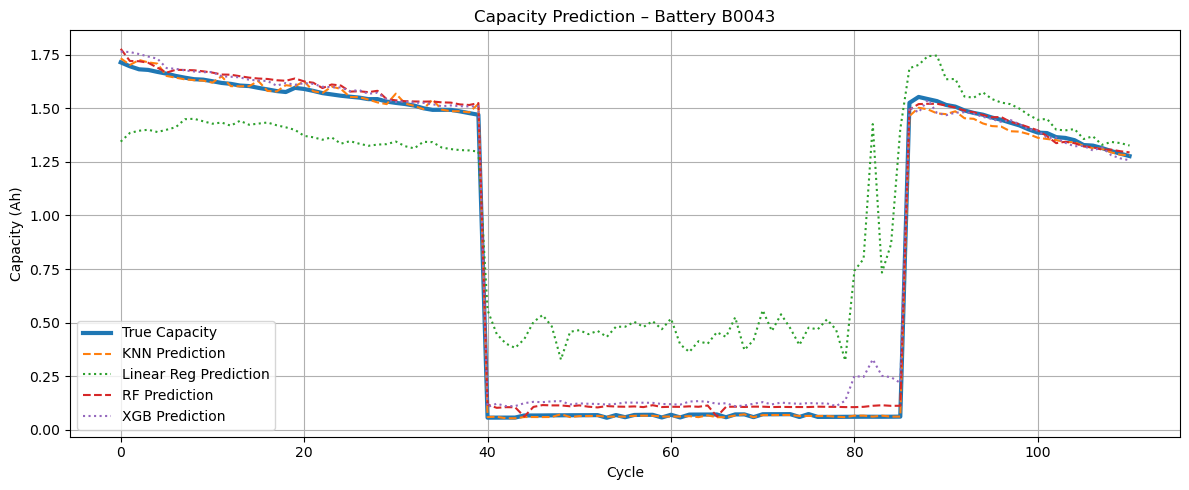

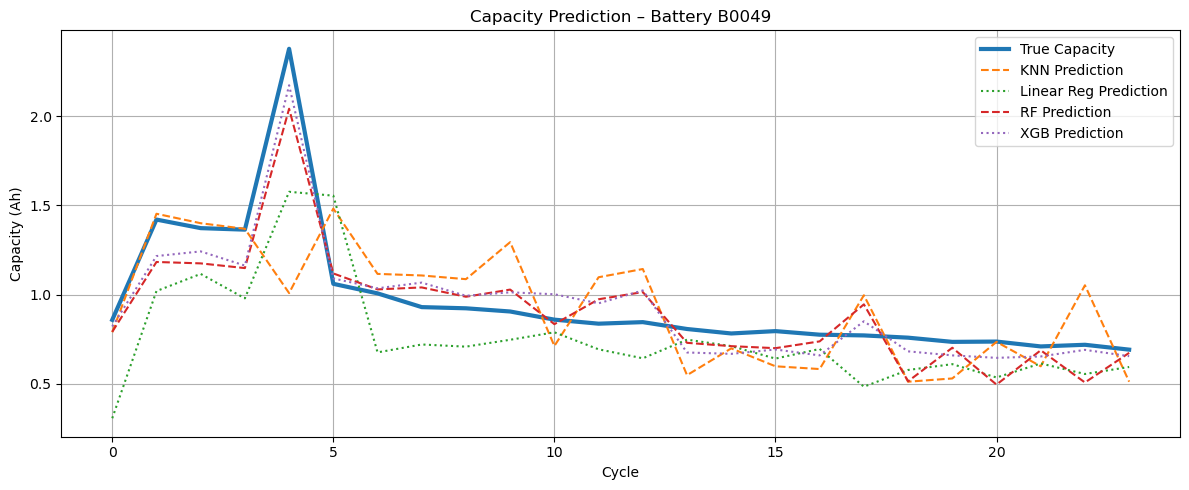

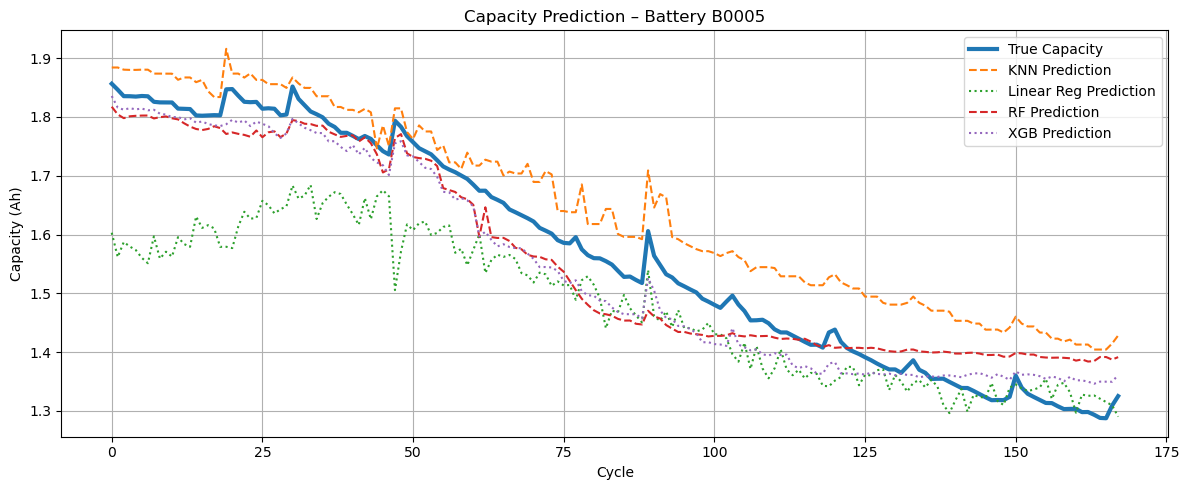

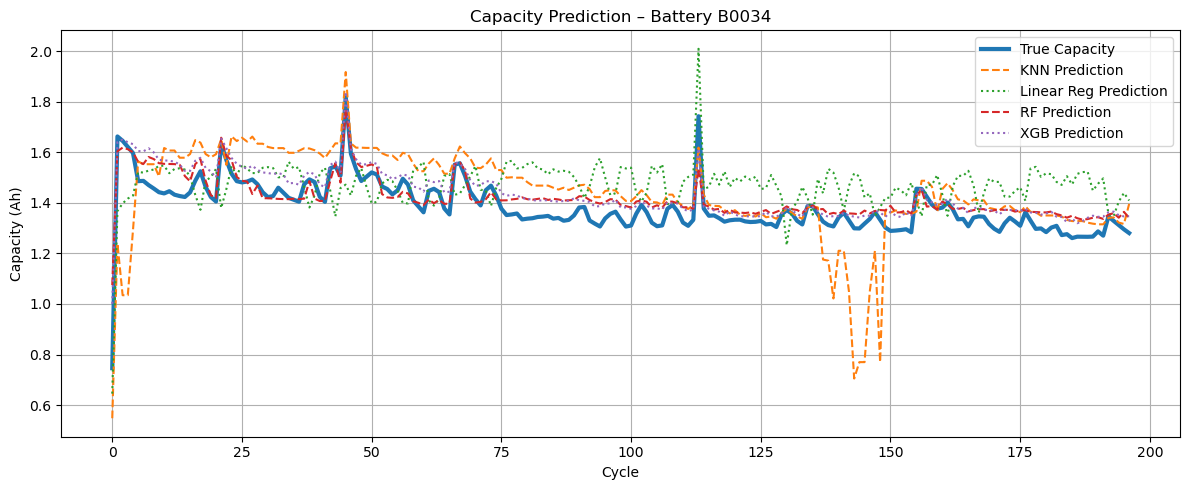

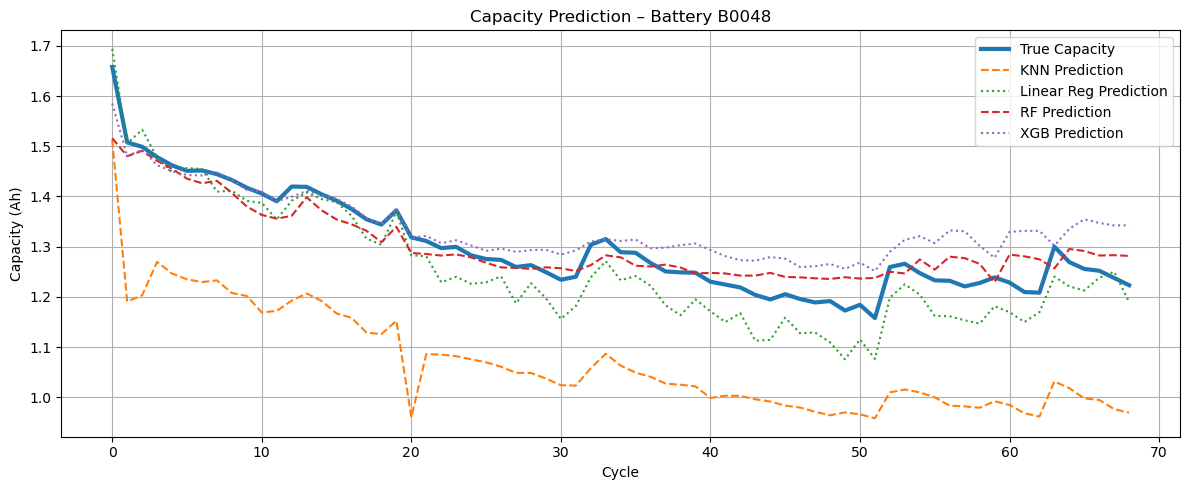

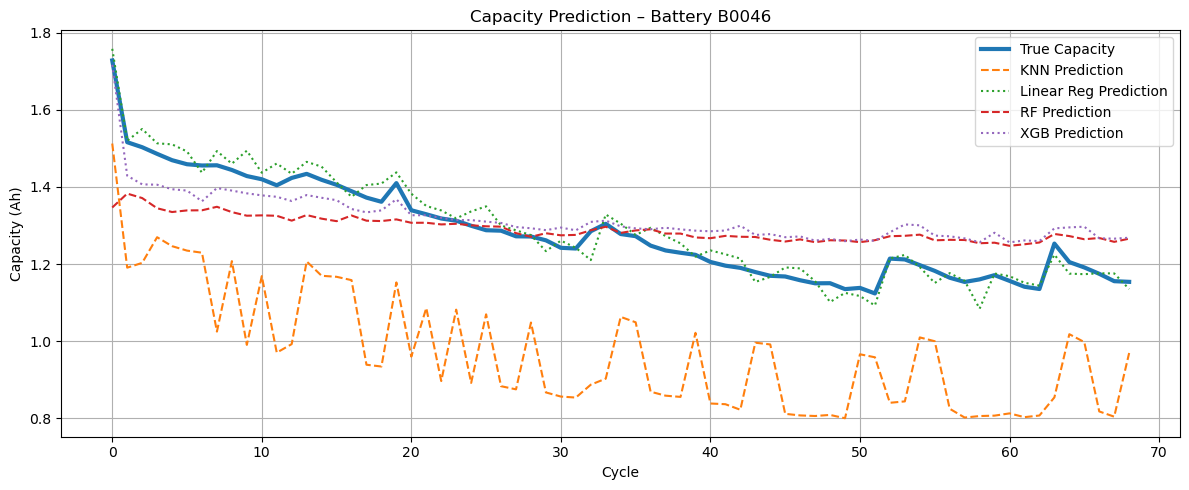

In [1833]:
def plot_capacity_for_battery(df, battery_id):
    d = df[df["battery_id"] == battery_id]
    
    if d.empty:
        print(f"No data for battery_id {battery_id}")
        return

    plt.figure(figsize=(12,5))

    x = np.arange(len(d))

    plt.plot(x, d["Capacity"], label="True Capacity", linewidth=3)
    plt.plot(x, d["pred_knn_cap"], label="KNN Prediction", linestyle="--")
    plt.plot(x, d["pred_lin_cap"], label="Linear Reg Prediction", linestyle=":")
    plt.plot(x, d["pred_rf_cap"], label="RF Prediction", linestyle="--")
    plt.plot(x, d["pred_xgb_cap"], label="XGB Prediction", linestyle=":")

    plt.title(f"Capacity Prediction – Battery {battery_id}")
    plt.xlabel("Cycle")
    plt.ylabel("Capacity (Ah)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

print(bat_val)
for bat in bat_val:
    plot_capacity_for_battery(dis_val, bat)

## Predicting RUL - val

In [1809]:
features = ['ambient_temperature', 
            'mean_voltage',
            'max_voltage',
            'min_voltage',
            'mean_current',
            'max_current',
            'mean_temperature',
            'max_temperature',
            'discharge_time',
            'r_internal', 
            'mean_dvdt', 
            'voltage_drop',
           'Rectified_impedance_phase_mean']

#had to remove cycle number because RUL depends too heavily on it, KNN got .9999 R2 score
target = 'RUL'
rulx_tr = dis_tr[features].values
ruly_tr = dis_tr[target].values
rulx_val = dis_val[features].values
ruly_val = dis_val[target].values

In [1811]:
ruly_tr

array([167, 166, 165, ...,   1,   1,   0])

In [1813]:
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    random_state=21
)
rf_model.fit(rulx_tr, ruly_tr)

rul_pred_rf = rf_model.predict(rulx_val)

print("RF MAE:", mean_absolute_error(ruly_val, rul_pred_rf))
print("RF MSE:", mean_squared_error(ruly_val, rul_pred_rf))
print("RF R2:", r2_score(ruly_val, rul_pred_rf))

dis_val["pred_rf_rul"]  = rul_pred_rf

'''
RF MAE: 11.027354849843297
RF MSE: 260.1294624379632
RF R2: 0.899037705136451
'''

RF MAE: 16.71395150911886
RF MSE: 467.42069480171307
RF R2: 0.8185831563575771


'\nRF MAE: 11.027354849843297\nRF MSE: 260.1294624379632\nRF R2: 0.899037705136451\n'

In [1814]:

xgb_model = xgb.XGBRegressor(
    n_estimators=600,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.7,
    colsample_bytree=0.8,
)

xgb_model.fit(rulx_tr, ruly_tr)
rul_pred_xgb = xgb_model.predict(rulx_val)
print("XGB MAE:", mean_absolute_error(ruly_val, rul_pred_xgb))
print("XGB MSE:", mean_squared_error(ruly_val, rul_pred_xgb))
print("XGB R2:", r2_score(ruly_val, rul_pred_xgb))

dis_val["pred_xgb_rul"]  = rul_pred_xgb

'''
XGB MAE: 11.027354849843297
XGB MSE: 260.1294624379632
XGB R2: 0.899037705136451
'''

XGB MAE: 17.511843266025668
XGB MSE: 485.4233201193359
XGB R2: 0.811595918739042


'\nXGB MAE: 11.027354849843297\nXGB MSE: 260.1294624379632\nXGB R2: 0.899037705136451\n'

In [1815]:
knn_model = KNeighborsRegressor(n_neighbors=2) 

knn_model.fit(rulx_tr, ruly_tr)

rul_pred_knn = knn_model.predict(rulx_val)

print("KNN MAE:", mean_absolute_error(ruly_val, rul_pred_knn))
print("KNN MSE:", mean_squared_error(ruly_val, rul_pred_knn))
print("KNN R2:", r2_score(ruly_val, rul_pred_knn))

dis_val["pred_knn_rul"]  = rul_pred_knn

KNN MAE: 4.298387096774194
KNN MSE: 63.4643300248139
KNN R2: 0.9753680173663107


In [1816]:
lin_model = LinearRegression()
lin_model.fit(rulx_tr, ruly_tr)

rul_pred_lin = lin_model.predict(rulx_val)

print("LIN MAE:", mean_absolute_error(ruly_val, rul_pred_lin))
print("LIN RMSE:", np.sqrt(mean_squared_error(ruly_val, rul_pred_lin)))
print("LIN R2:", r2_score(ruly_val, rul_pred_lin))

dis_val["pred_lin_rul"]  = rul_pred_lin

LIN MAE: 36.814868315135676
LIN RMSE: 44.88546677148853
LIN R2: 0.21804607898456996


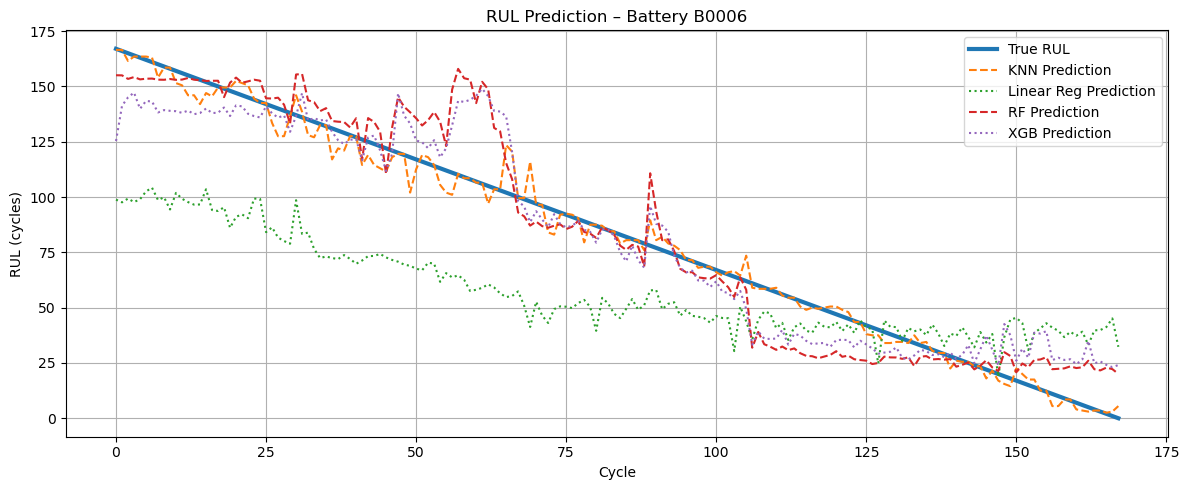

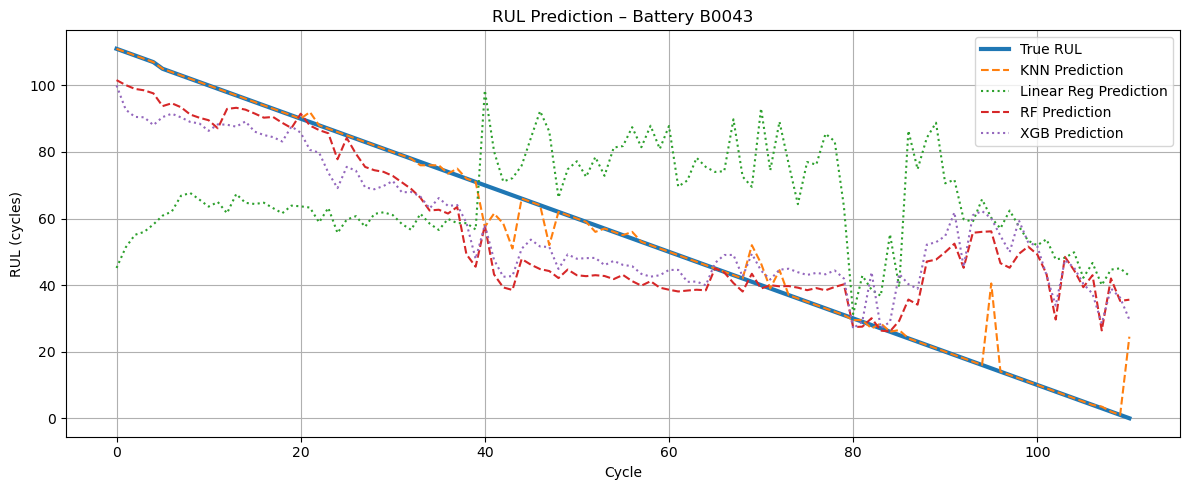

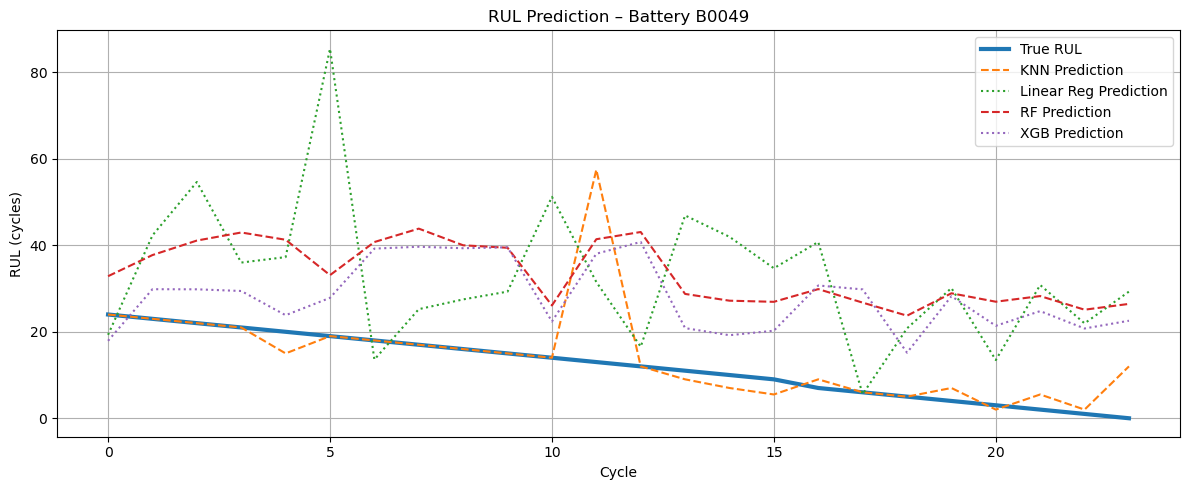

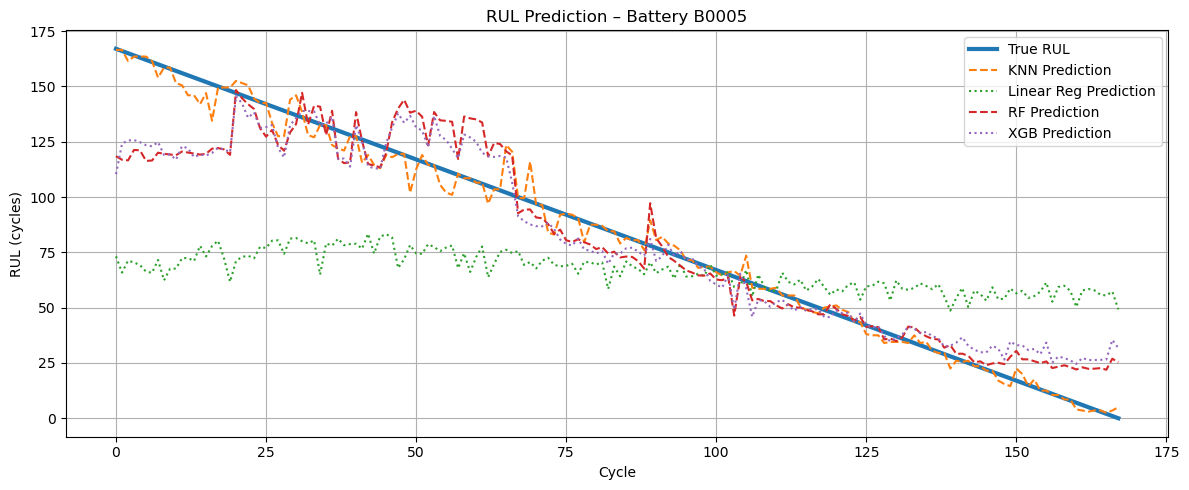

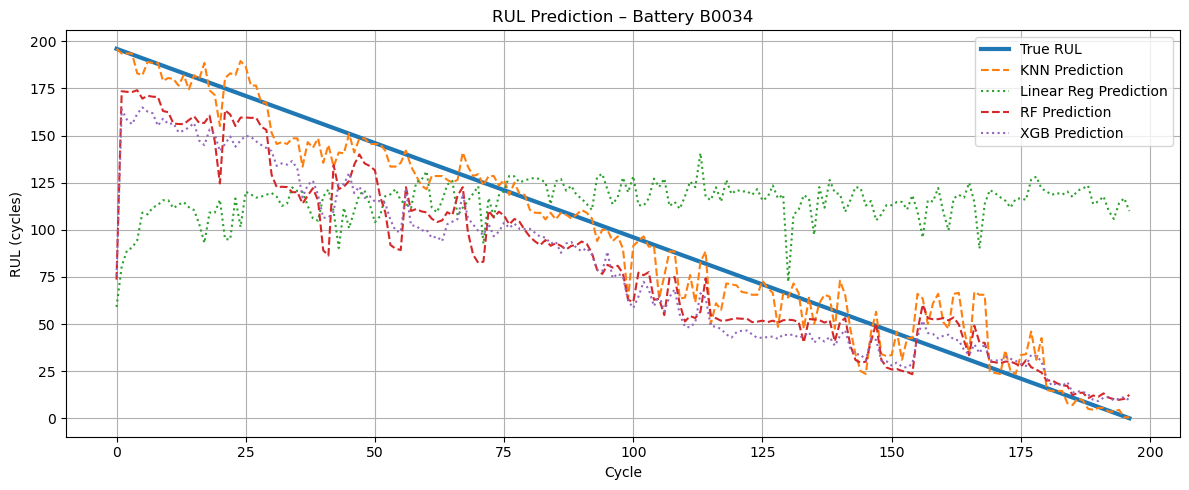

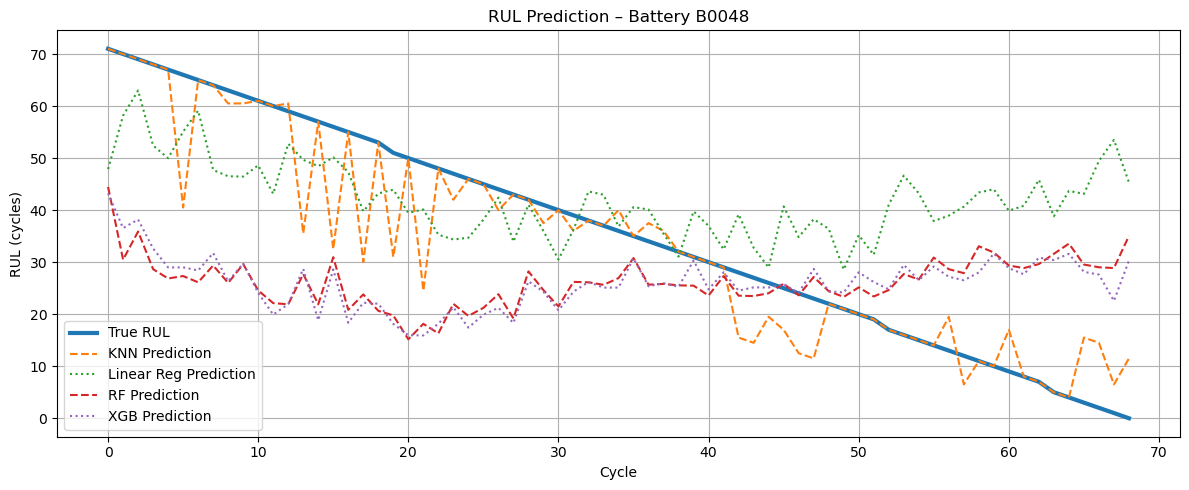

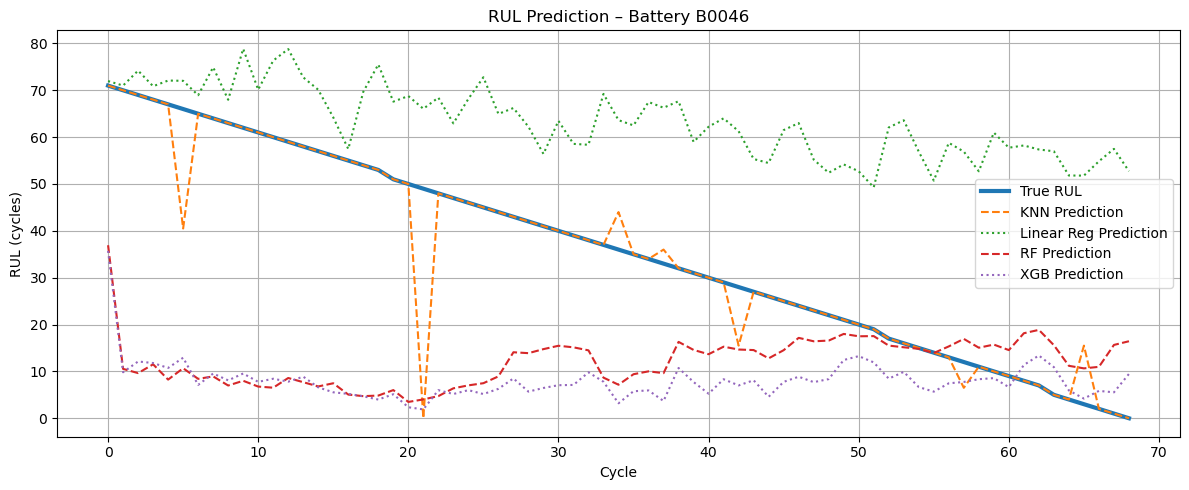

In [1835]:
def plot_rul_for_battery(df, battery_id):
    d = df[df["battery_id"] == battery_id]
    
    if d.empty:
        print(f"No data for battery_id {battery_id}")
        return

    plt.figure(figsize=(12,5))

    x = np.arange(len(d))

    plt.plot(x, d["RUL"], label="True RUL", linewidth=3)
    plt.plot(x, d["pred_knn_rul"], label="KNN Prediction", linestyle="--")
    plt.plot(x, d["pred_lin_rul"], label="Linear Reg Prediction", linestyle=":")
    plt.plot(x, d["pred_rf_rul"], label="RF Prediction", linestyle="--")
    plt.plot(x, d["pred_xgb_rul"], label="XGB Prediction", linestyle=":")

    plt.title(f"RUL Prediction – Battery {battery_id}")
    plt.xlabel("Cycle")
    plt.ylabel("RUL (cycles)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

for bat in bat_val:
    plot_rul_for_battery(dis_val, bat)

## Capacity and RUL - Test Sets

In [1839]:
bat_tr, bat_te = train_test_split(BATTERIES, test_size=0.24, random_state=21)
print(bat_tr)
print(bat_te)

df_tr = df[df['battery_id'].isin(bat_tr)]
df_te = df[df['battery_id'].isin(bat_te)]
dis_tr = pp.get_discharges_phyiscs(path, df_tr)
dis_te = pp.get_discharges_phyiscs(path, df_te)
dis_tr = pp.merge_impedance_with_discharges(df_tr, dis_tr, path)
dis_te = pp.merge_impedance_with_discharges(df_te, dis_te, path)

['B0042', 'B0045', 'B0028', 'B0050', 'B0032', 'B0041', 'B0027', 'B0053', 'B0044', 'B0051', 'B0056', 'B0033', 'B0036', 'B0029', 'B0031', 'B0040', 'B0007', 'B0018', 'B0054', 'B0052', 'B0039', 'B0025', 'B0047', 'B0038', 'B0030']
['B0006', 'B0043', 'B0049', 'B0005', 'B0034', 'B0048', 'B0046', 'B0055', 'B0026']


In [1840]:
features = ['ambient_temperature', 
            'cycle_number',
            'mean_voltage',
            'max_voltage',
            'min_voltage',
            'mean_current',
            'max_current',
            'mean_temperature',
            'max_temperature',
            'discharge_time',
            'r_internal', 
            'mean_dvdt', 
            'voltage_drop',
            'Rectified_impedance_phase_mean']
target = 'Capacity'

disx_tr = dis_tr[features].values
disy_tr = dis_tr[target].values
disx_te = dis_te[features].values
disy_te = dis_te[target].values

In [1841]:
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    random_state=21
)
rf_model.fit(disx_tr, disy_tr)

pred_rf = rf_model.predict(disx_te)

print("RF MAE:", mean_absolute_error(disy_te, pred_rf))
print("RF MSE:", mean_squared_error(disy_te, pred_rf))
print("RF R2:", r2_score(disy_te, pred_rf))

dis_te["pred_rf_cap"]  = pred_rf

RF MAE: 0.06338642774669538
RF MSE: 0.006764352168217266
RF R2: 0.9530953575850568


In [1842]:
xgb_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.02,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=21
)

xgb_model.fit(disx_tr, disy_tr)

pred_xgb = xgb_model.predict(disx_te)

print("XGB MAE:", mean_absolute_error(disy_te, pred_xgb))
print("XGB RMSE:", np.sqrt(mean_squared_error(disy_te, pred_xgb)))
print("XGB R2:", r2_score(disy_te, pred_xgb))

dis_te["pred_xgb_cap"]  = pred_xgb

XGB MAE: 0.05632768085527429
XGB RMSE: 0.07066876850223748
XGB R2: 0.9653706239984963


In [1843]:
knn_model = KNeighborsRegressor(n_neighbors=3) 

knn_model.fit(disx_tr, disy_tr)

pred_knn = knn_model.predict(disx_te)

print("KNN MAE:", mean_absolute_error(disy_te, pred_knn))
print("KNN RMSE:", np.sqrt(mean_squared_error(disy_te, pred_knn)))
print("KNN R2:", r2_score(disy_te, pred_knn))

dis_te["pred_knn_cap"]  = pred_knn

KNN MAE: 0.11287626757514295
KNN RMSE: 0.1575764446446127
KNN R2: 0.8278241585017827


In [1844]:
lin_model = LinearRegression()
lin_model.fit(disx_tr, disy_tr)

pred_lin = lin_model.predict(disx_te)

print("LIN MAE:", mean_absolute_error(disy_te, pred_lin))
print("LIN RMSE:", np.sqrt(mean_squared_error(disy_te, pred_lin)))
print("LIN R2:", r2_score(disy_te, pred_lin))

dis_te["pred_lin_cap"]  = pred_lin

LIN MAE: 0.1338837300906455
LIN RMSE: 0.18086324497571118
LIN R2: 0.7731753462959674


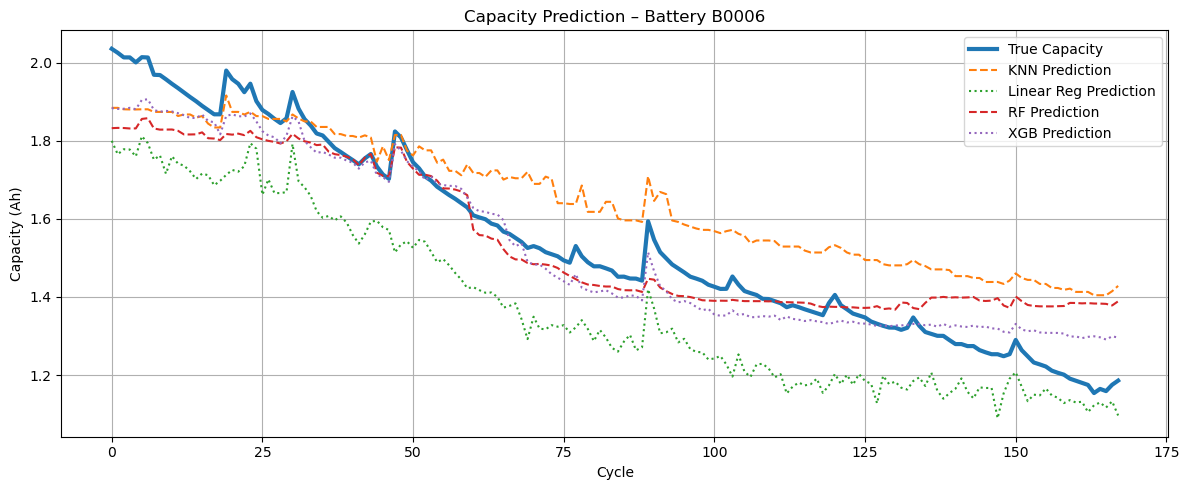

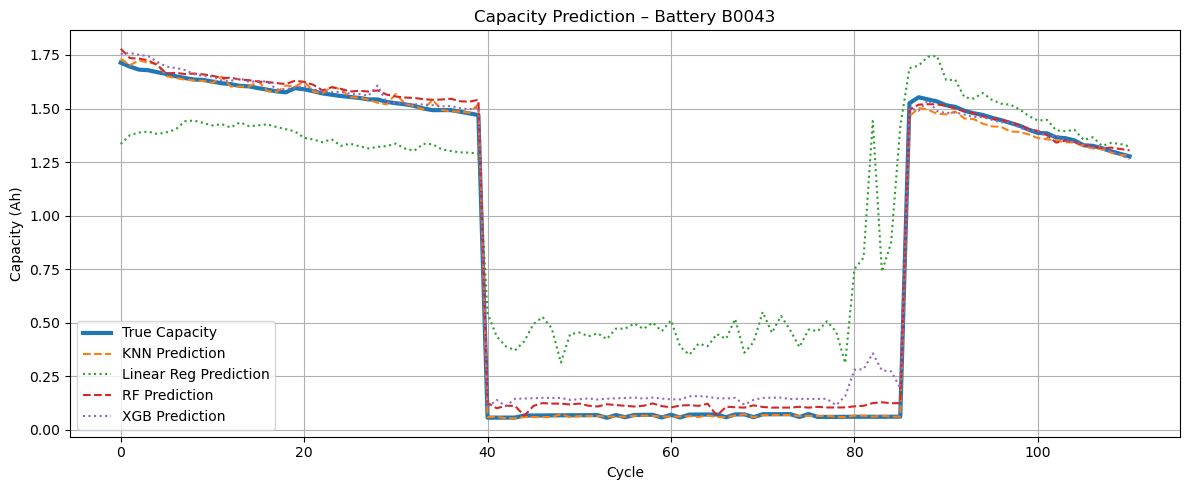

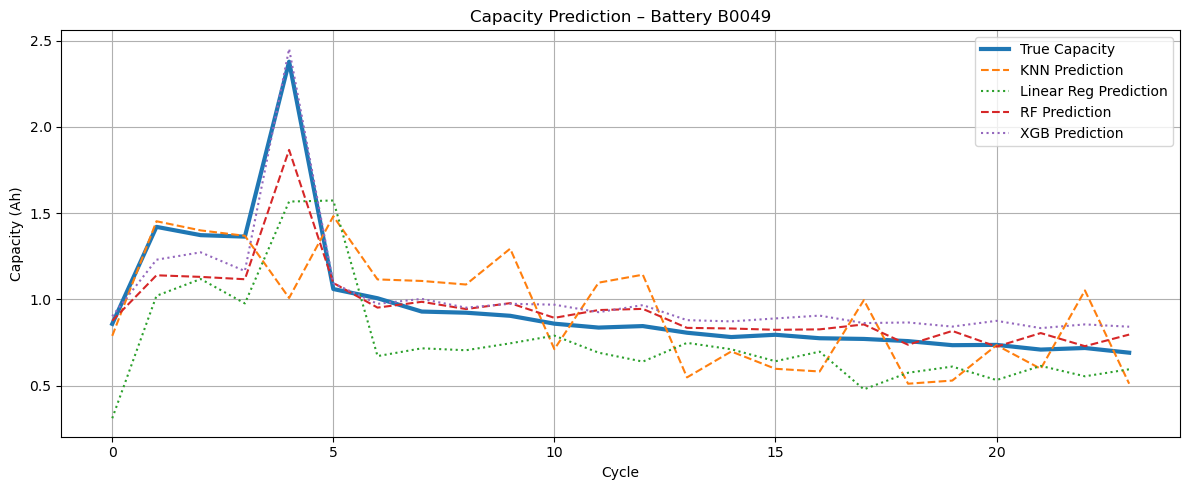

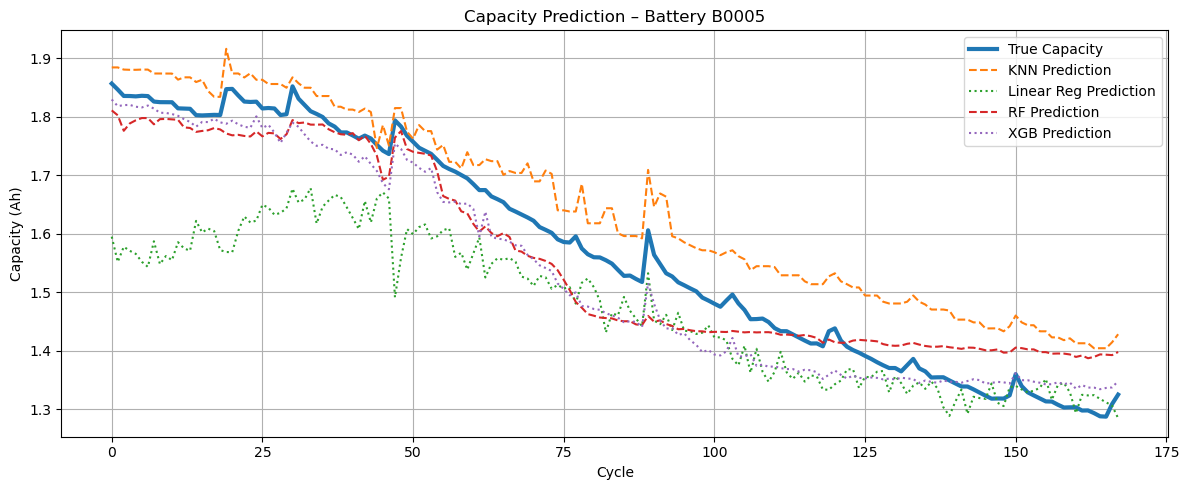

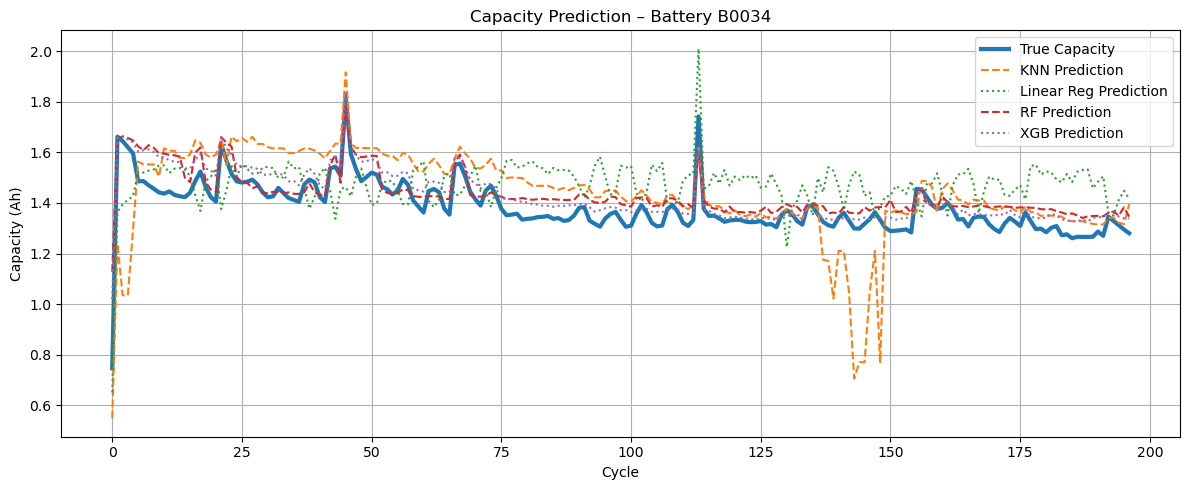

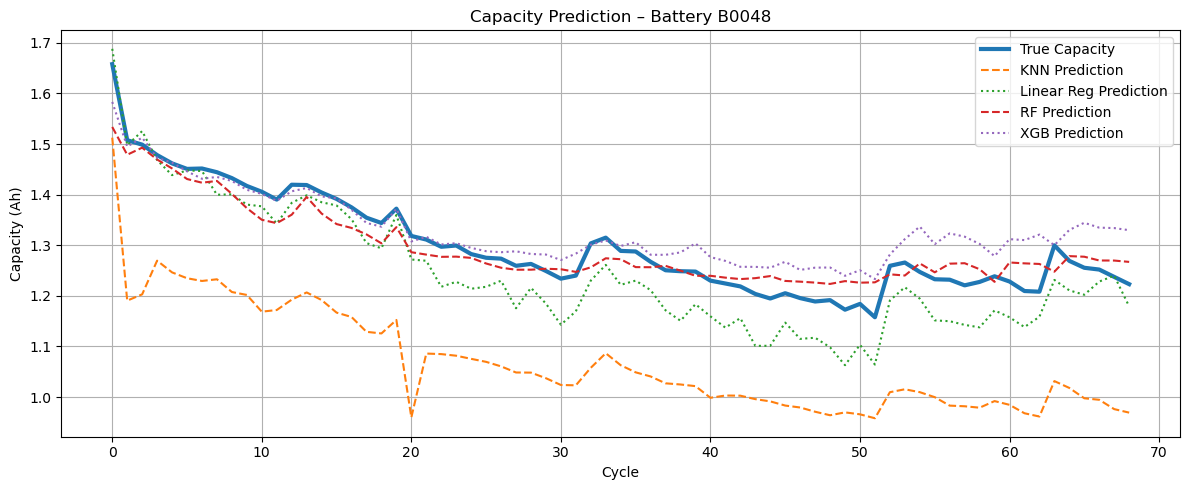

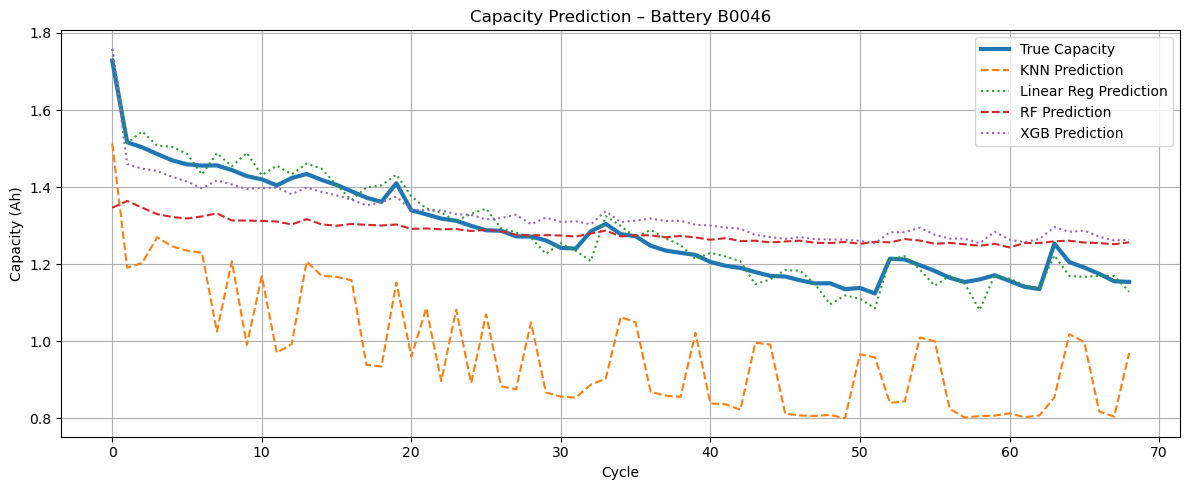

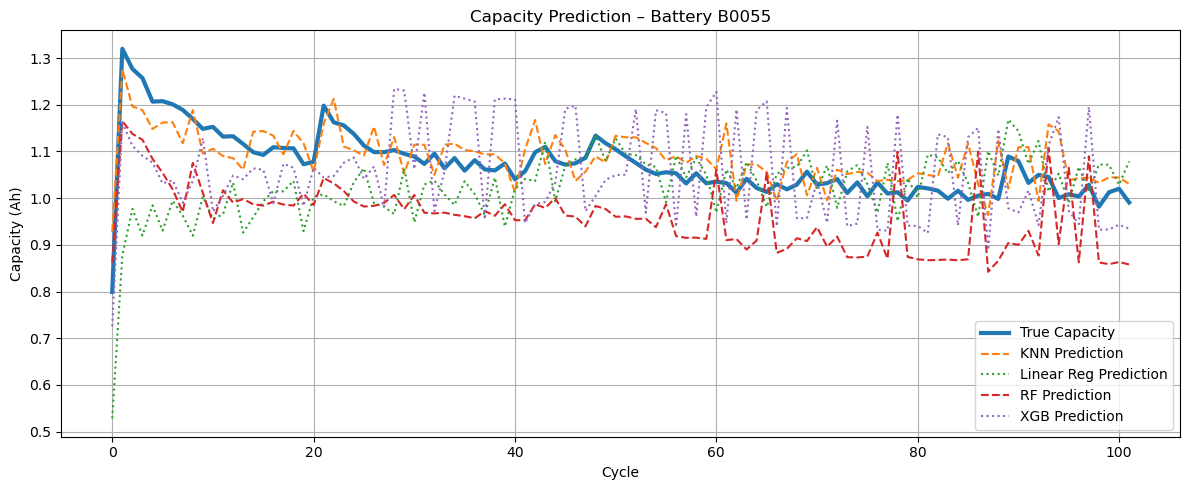

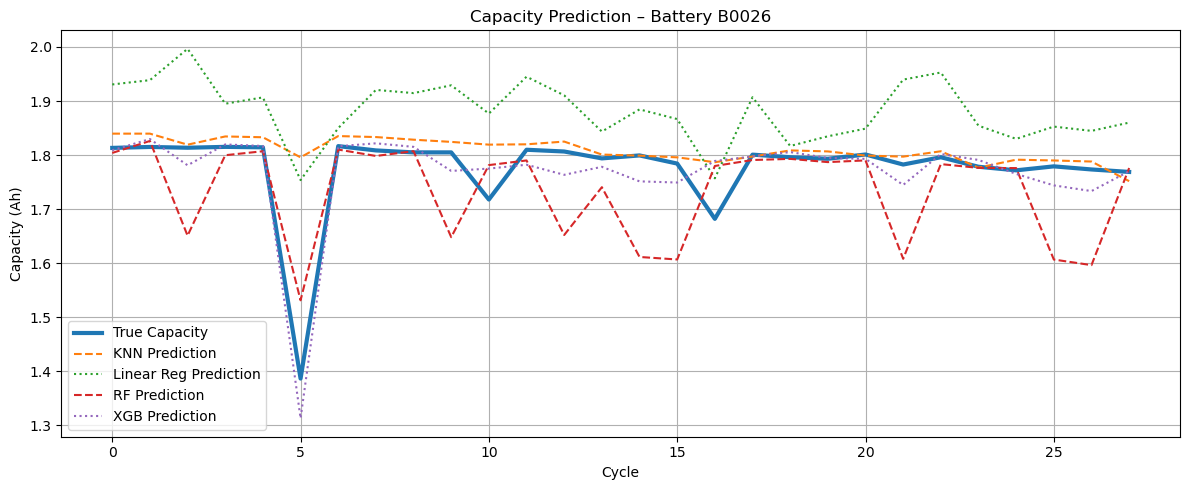

In [1845]:
for bat in bat_te:
    plot_capacity_for_battery(dis_te, bat)

In [1853]:
features = ['ambient_temperature', 
            'mean_voltage',
            'max_voltage',
            'min_voltage',
            'mean_current',
            'max_current',
            'mean_temperature',
            'max_temperature',
            'discharge_time',
            'r_internal', 
            'mean_dvdt', 
            'voltage_drop']

#had to remove cycle number because RUL depends too heavily on it, KNN got .9999 R2 score
target = 'RUL'
rulx_tr = dis_tr[features].values
ruly_tr = dis_tr[target].values
rulx_te = dis_te[features].values
ruly_te = dis_te[target].values

In [1855]:
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    random_state=21
)
rf_model.fit(rulx_tr, ruly_tr)

rul_pred_rf = rf_model.predict(rulx_te)

print("RF MAE:", mean_absolute_error(ruly_te, rul_pred_rf))
print("RF MSE:", mean_squared_error(ruly_te, rul_pred_rf))
print("RF R2:", r2_score(ruly_te, rul_pred_rf))

dis_te["pred_rf_rul"]  = rul_pred_rf

RF MAE: 17.653108804116677
RF MSE: 530.5450237548629
RF R2: 0.7840867315762662


In [1856]:
xgb_model = xgb.XGBRegressor(
    n_estimators=600,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.7,
    colsample_bytree=0.8,
)

xgb_model.fit(rulx_tr, ruly_tr)
rul_pred_xgb = xgb_model.predict(rulx_te)

print("XGB MAE:", mean_absolute_error(ruly_te, rul_pred_xgb))
print("XGB MSE:", mean_squared_error(ruly_te, rul_pred_xgb))
print("XGB R2:", r2_score(ruly_te, rul_pred_xgb))

dis_te["pred_xgb_rul"]  = rul_pred_xgb

XGB MAE: 18.740673701875867
XGB MSE: 567.0336906539909
XGB R2: 0.769237120369177


In [1857]:
knn_model = KNeighborsRegressor(n_neighbors=2) 

knn_model.fit(rulx_tr, ruly_tr)

rul_pred_knn = knn_model.predict(rulx_te)

print("KNN MAE:", mean_absolute_error(ruly_te, rul_pred_knn))
print("KNN MSE:", mean_squared_error(ruly_te, rul_pred_knn))
print("KNN R2:", r2_score(ruly_te, rul_pred_knn))

dis_te["pred_knn_rul"]  = rul_pred_knn

KNN MAE: 4.5747863247863245
KNN MSE: 73.56784188034187
KNN R2: 0.9700604614499139


In [1858]:
lin_model = LinearRegression()
lin_model.fit(rulx_tr, ruly_tr)

rul_pred_lin = lin_model.predict(rulx_te)

print("LIN MAE:", mean_absolute_error(ruly_te, rul_pred_lin))
print("LIN RMSE:", np.sqrt(mean_squared_error(ruly_te, rul_pred_lin)))
print("LIN R2:", r2_score(ruly_te, rul_pred_lin))

dis_te["pred_lin_rul"]  = rul_pred_lin

LIN MAE: 37.077775429395686
LIN RMSE: 44.69266553534487
LIN R2: 0.18711408036373822


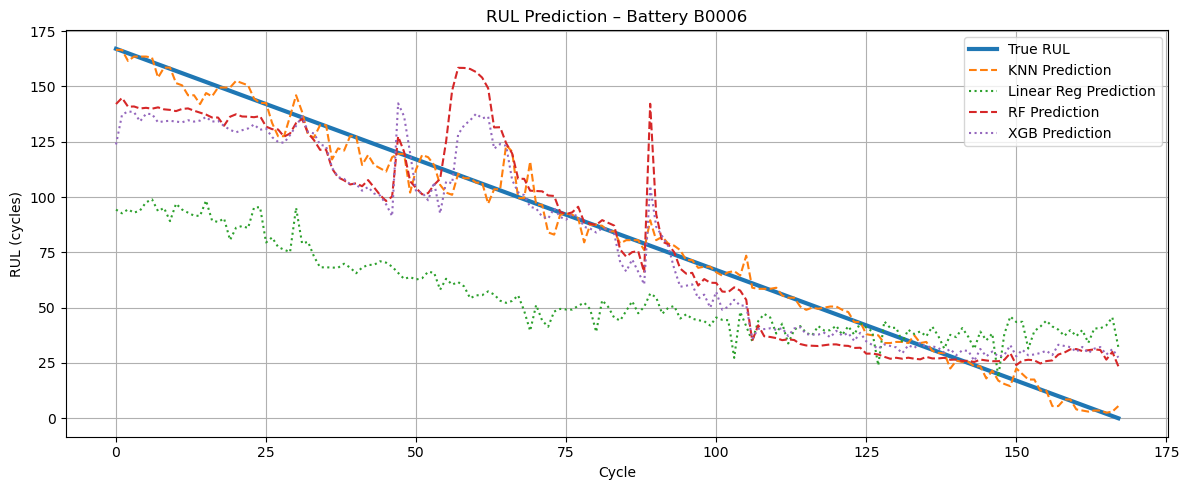

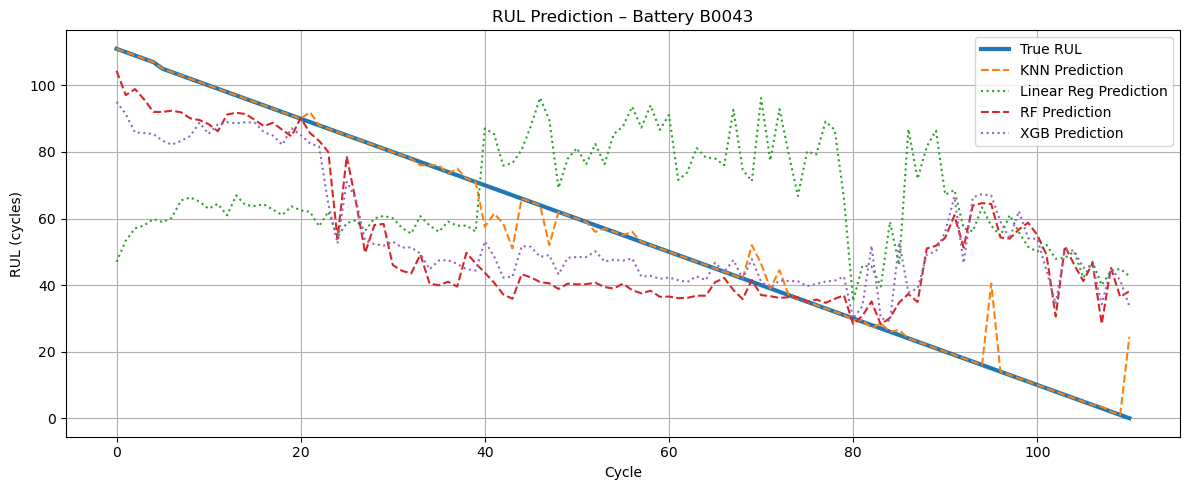

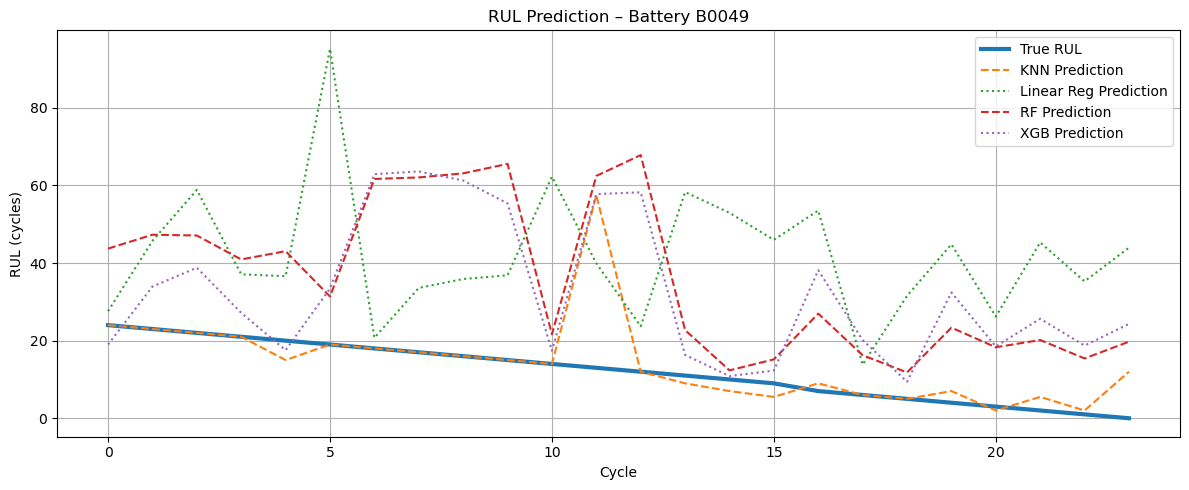

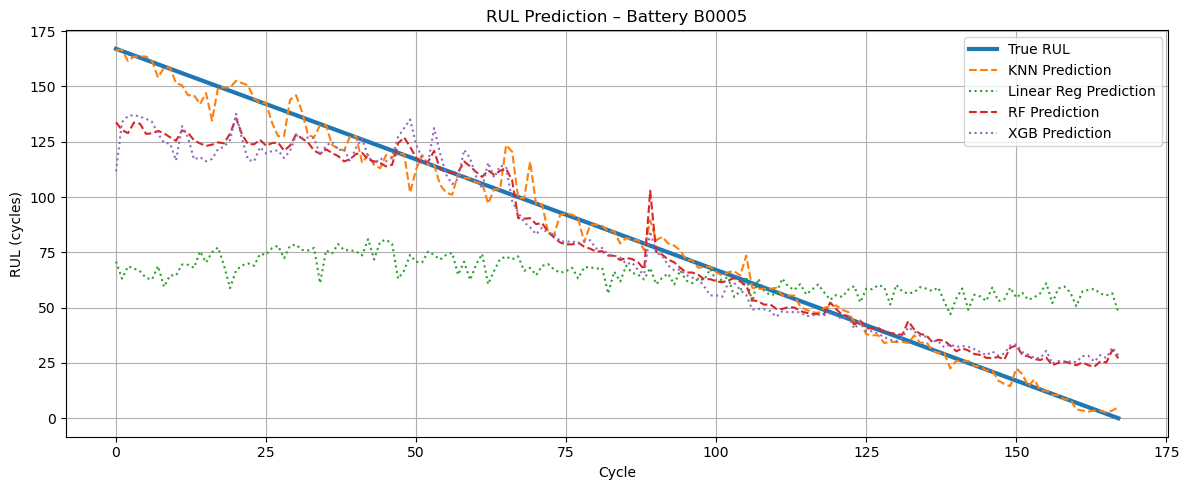

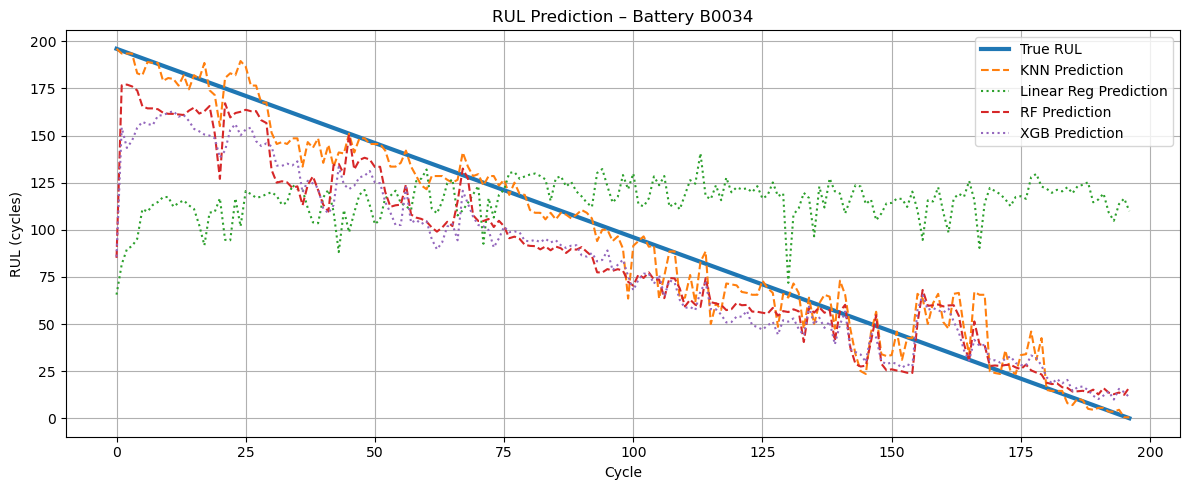

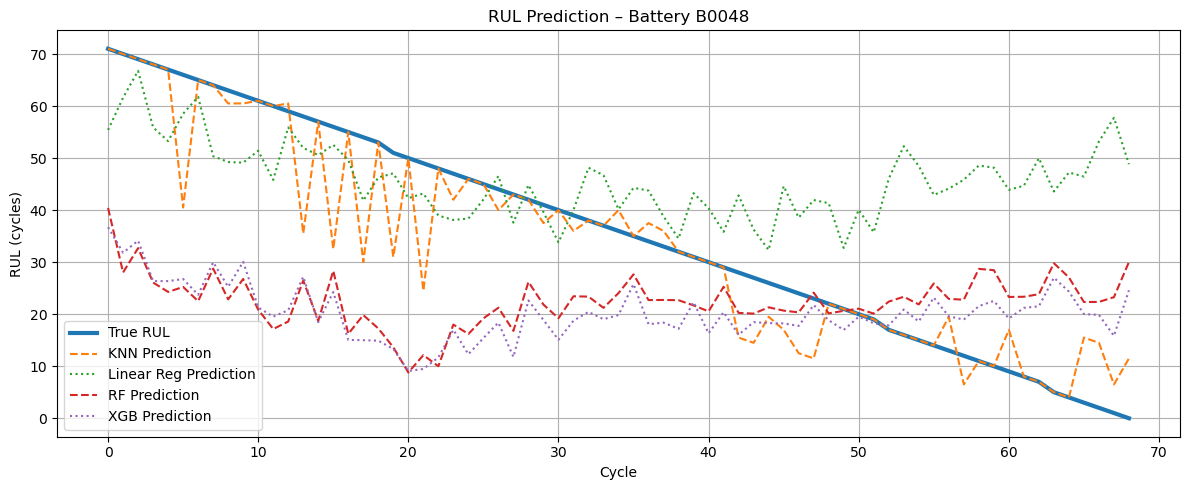

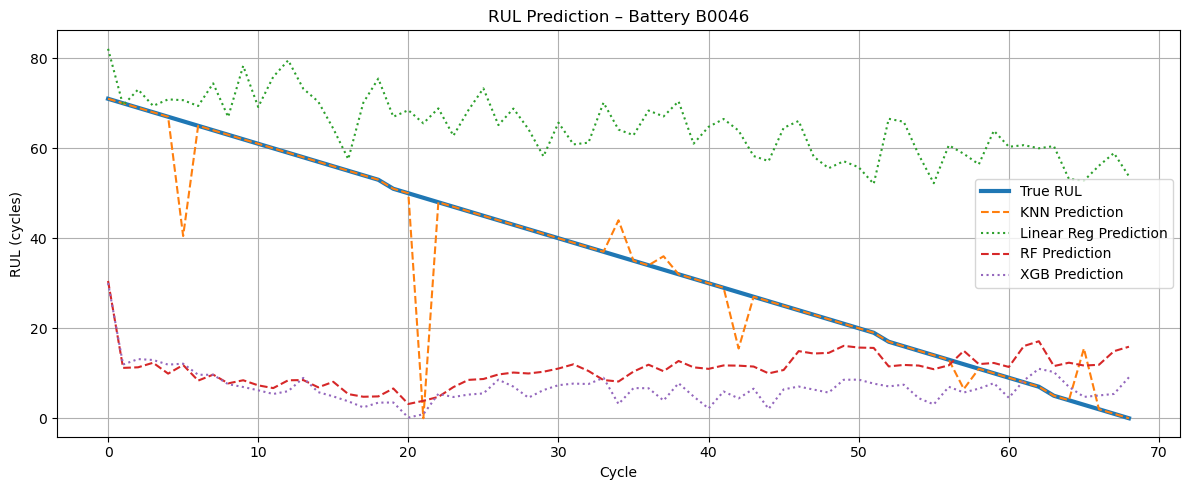

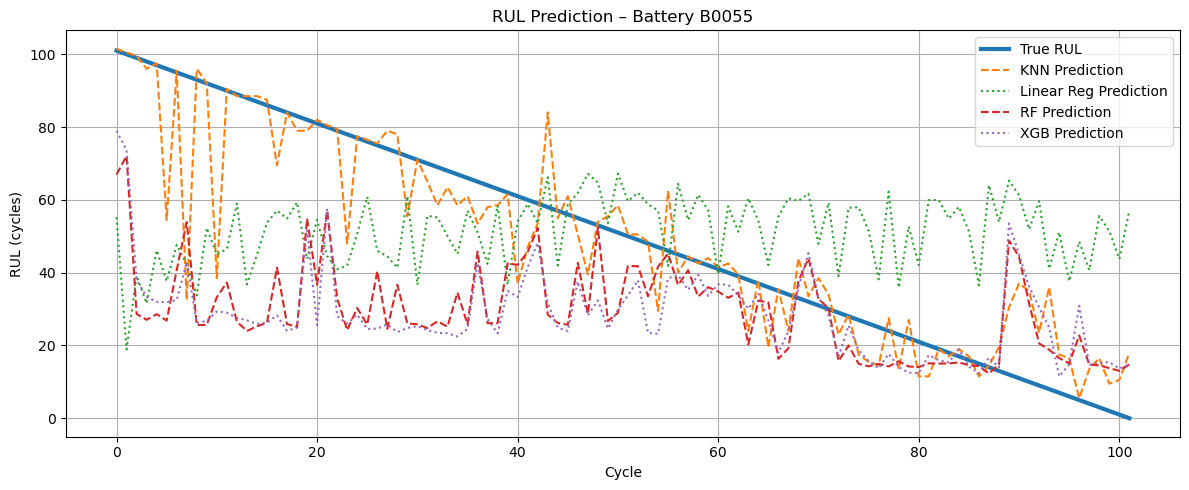

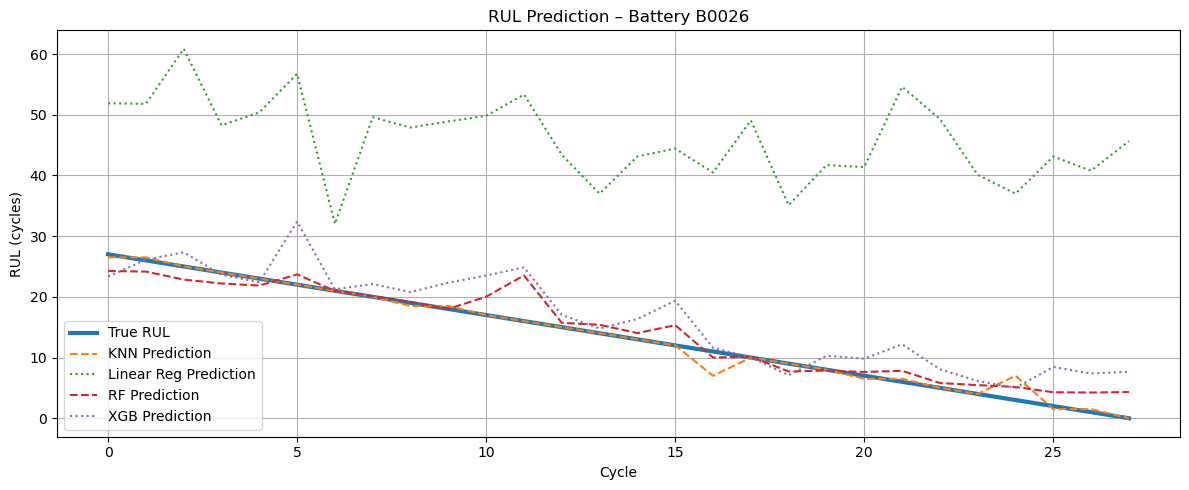

In [1859]:
for bat in bat_te:
    plot_rul_for_battery(dis_te, bat)

## Physics Modeling

In [1249]:
df_dis = pp.get_discharges_phyiscs(path, df)
df_dis = pp.merge_impedance_with_discharges(df, df_dis, path)
#df[df['battery_id'] == 'B0052' & df['type'] == 'discharge']
#df[(df['battery_id'] == 'B0026') & (df['type'] == 'discharge')]
df_dis

,start_time,ambient_temperature,battery_id,uid,filename,Capacity,cycle_number,SOH,EOL_cycle,RUL,...,discharge_time,r_internal,mean_dvdt,capacity_Ah,capacity_ratio,voltage_drop,Battery_impedance_real_mean,Battery_impedance_mag_mean,Rectified_impedance_real_mean,Rectified_impedance_phase_mean
0,2008-04-02 15:25:41.593000,24,B0006,4506,04506.csv,2.035338,1,1.017669,168,167,...,3690.234,0.019859,-0.000465,2.046703,1.005584,1.704032,0.173923,0.190841,0.071337,-0.012372
1,2008-04-02 15:25:41.593000,24,B0007,5738,05738.csv,1.891052,1,0.945526,168,167,...,3690.234,0.020113,-0.000305,1.919029,1.014795,1.137247,0.165188,0.185893,0.051705,-0.017040
2,2008-04-02 15:25:41.593000,24,B0005,5122,05122.csv,1.856487,1,0.928244,168,167,...,3690.234,0.019875,-0.000249,1.862203,1.003079,0.914322,0.171894,0.208950,0.059184,-0.017650
3,2008-04-02 19:43:48.405999,24,B0005,5124,05124.csv,1.846327,2,0.923164,168,166,...,3672.344,0.019855,-0.000244,1.852078,1.003115,0.889528,0.171894,0.208950,0.059184,-0.017650
4,2008-04-02 19:43:48.405999,24,B0006,4508,04508.csv,2.025140,2,1.012570,168,166,...,3672.344,0.019882,-0.000502,2.036566,1.005642,1.825763,0.173923,0.190841,0.071337,-0.012372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2745,2010-09-30 08:08:36.328000,4,B0054,7057,07057.csv,0.852452,101,0.426226,103,2,...,2322.000,0.019887,-0.000214,1.187843,1.393443,0.505210,0.257711,0.262117,0.129947,-0.037604
2746,2010-09-30 11:50:17.687000,4,B0053,6806,06806.csv,1.010274,55,0.505137,56,1,...,2357.687,0.019885,-0.000935,1.308950,1.295638,2.258601,0.288265,0.294110,0.130685,-0.030323
2747,2010-09-30 11:50:17.687000,4,B0056,7312,07312.csv,1.129059,102,0.564530,102,0,...,2357.687,0.020089,-0.000173,1.132795,1.003309,0.454627,0.262476,0.266944,0.131623,-0.035036
2748,2010-09-30 11:50:17.687000,4,B0054,7059,07059.csv,0.837392,102,0.418696,103,1,...,2357.687,0.019872,-0.000227,1.223278,1.460819,0.565554,0.257711,0.262117,0.129947,-0.037604


In [1209]:
def linear_model(n, Q0, k):
    # Q(n) = Q0 - k*n  (k is positive decay rate)
    return Q0 - k * n

def sqrt_model(n, Q0, a, b):
    # Q(n) = Q0 - a*n - b*sqrt(n)  (keeps both linear + sqrt)
    return Q0 - a * n - b * np.sqrt(n)

def exponential_model(n, Q0, k):
    # Q(n) = Q0 * exp(-k * n)
    return Q0 * np.exp(-k * n)

# resistance models
def resistance_linear(n, R0, alpha):
    return R0 + alpha * n

def resistance_sqrt(n, R0, beta):
    return R0 + beta * np.sqrt(n)

# Metrics
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def safe_array(x):
    return np.array(x, dtype=float)

In [1210]:
def fit_capacity_models_per_battery(df, cycles_col='cycle_number', cap_col='Capacity', min_points=6):
    """
    Fit several physics capacity models per battery and select best by RMSE.
    Returns dict with battery_id -> dict of chosen model and params and diagnostics.
    """
    results = {}
    for bid, g in df.groupby('battery_id'):
        g = g.sort_values(cycles_col)
        x = safe_array(g[cycles_col])
        y = safe_array(g[cap_col])

        # skip if too few points
        if len(x) < min_points or np.isnan(y).all():
            results[bid] = {'error': 'too_few_points'}
            continue

        best = {'rmse': np.inf, 'model': None, 'popt': None, 'pred': None}

        # try linear (Q0 - k n)
        try:
            p_lin, _ = curve_fit(linear_model, x, y, p0=[y[0], 1e-3], maxfev=10000)
            pred_lin = linear_model(x, *p_lin)
            rmse_lin = rmse(y, pred_lin)
            if rmse_lin < best['rmse']:
                best.update({'rmse': rmse_lin, 'model': 'linear', 'popt': p_lin, 'pred': pred_lin})
        except Exception as e:
            print(f'error1: {e}')
            pass

        # try linear+sqrt
        try:
            p_sqrt, _ = curve_fit(sqrt_model, x, y, p0=[y[0], 1e-4, 1e-3], maxfev=20000, bounds=([-np.inf,0,0],[np.inf, np.inf, np.inf]))
            pred_sqrt = sqrt_model(x, *p_sqrt)
            rmse_sqrt = rmse(y, pred_sqrt)
            if rmse_sqrt < best['rmse']:
                best.update({'rmse': rmse_sqrt, 'model': 'sqrt', 'popt': p_sqrt, 'pred': pred_sqrt})
        except Exception as e:
            print(f'error2: {e}')
            pass

        # try exponential
        try:
            # fit log if all positive
            if (y > 0).all():
                p_exp, _ = curve_fit(exponential_model, x, y, p0=[y[0], 1e-4], maxfev=10000)
                pred_exp = exponential_model(x, *p_exp)
                rmse_exp = rmse(y, pred_exp)
                if rmse_exp < best['rmse']:
                    best.update({'rmse': rmse_exp, 'model': 'exp', 'popt': p_exp, 'pred': pred_exp})
        except Exception as e:
            print(f'error3: {e}')
            pass

        results[bid] = {
            'best_rmse': best['rmse'],
            'best_model': best['model'],
            'popt': best['popt'],
            'y_true': y,
            'y_fit': best['pred'],
            'cycles': x
        }

    return results

In [1211]:
def fit_resistance_per_battery(df, cycles_col='cycle_number', res_col='r_internal', min_points=5):
    results = {}
    for bid, g in df.groupby('battery_id'):
        g = g.sort_values(cycles_col)
        x = safe_array(g[cycles_col])
        y = safe_array(g[res_col])

        if len(x) < min_points or np.all(np.isnan(y)):
            results[bid] = {'error':'too_few_points'}
            continue

        best = {'rmse': np.inf, 'model': None, 'popt': None, 'pred': None}
        # linear
        try:
            p_lin = np.polyfit(x, y, 1)
            pred_lin = np.polyval(p_lin, x)
            rmse_lin = rmse(y, pred_lin)
            if rmse_lin < best['rmse']:
                best.update({'rmse': rmse_lin, 'model': 'linear', 'popt': p_lin, 'pred': pred_lin})
        except Exception as e:
            print(f'error4: {e}')
            pass

        # sqrt fit
        try:
            popt, _ = curve_fit(resistance_sqrt, x, y, p0=[y[0], 1e-4], maxfev=10000)
            pred_sqrt = resistance_sqrt(x, *popt)
            rmse_sqrt = rmse(y, pred_sqrt)
            if rmse_sqrt < best['rmse']:
                best.update({'rmse': rmse_sqrt, 'model': 'sqrt', 'popt': popt, 'pred': pred_sqrt})
        except Exception as e:
            print(f'error5: {e}')
            pass
            
        results[bid] = {
            'best_rmse': best['rmse'],
            'best_model': best['model'],
            'popt': best['popt'],
            'y_true': y,
            'y_fit': best['pred'],
            'cycles': x
        }
    return results

In [1212]:
def predict_physics_capacity_for_battery(bid, cycles, cap_model_entry):
    model = cap_model_entry.get('best_model')
    popt = cap_model_entry.get('popt')

    #if model/popt is missing, fall back to linear approximation
    if model is None or popt is None:
        # fallback = very weak degradation slope (nearly flat)
        # Q0 = first cycle capacity estimate? If not, assume 1.0
        Q0 = cap_model_entry.get("Q0_backup", 1.0)
        k = cap_model_entry.get("k_backup", 0.0)
        return linear_model(cycles, Q0, k)
    
    # Normal behavior
    if model == 'linear':
        Q0, k = popt
        return linear_model(cycles, Q0, k)
    elif model == 'sqrt':
        Q0, a, b = popt
        return sqrt_model(cycles, Q0, a, b)
    elif model == 'exp':
        Q0, k = popt
        return exponential_model(cycles, Q0, k)
    else:
        # unknown model → fallback
        Q0 = cap_model_entry.get("Q0_backup", 1.0)
        k = cap_model_entry.get("k_backup", 0.0)
        return linear_model(cycles, Q0, k)

def compute_physics_predictions_and_rul(df, cap_models, res_models,
                                        eol_frac=0.8, future_horizon=1000):

    rows = []
    per_batt_EOL = {}

    for bid, g in df.groupby("battery_id"):
        g = g.sort_values("cycle_number").reset_index(drop=True)

        cycles_obs = g["cycle_number"].values.astype(float)
        caps_obs = g["Capacity"].values.astype(float)

        cap_entry = cap_models.get(bid, {})

        # ----------------------------------------------------
        # FALLBACK: if fitted model missing → create backup linear parameters
        # ----------------------------------------------------
        if cap_entry.get("best_model") is None or cap_entry.get("popt") is None:
            # simple linear regression fit: C ≈ Q0 - k * cycle
            if len(cycles_obs) > 1 and not np.all(np.isnan(caps_obs)):
                # robust: ignore NaNs
                mask = ~np.isnan(caps_obs)
                if mask.sum() >= 2:
                    p = np.polyfit(cycles_obs[mask], caps_obs[mask], 1)
                    k_backup = -p[0]
                    Q0_backup = p[1]
                else:
                    Q0_backup, k_backup = caps_obs[0], 0.0
            else:
                Q0_backup, k_backup = 1.0, 0.0

            cap_entry["Q0_backup"] = float(Q0_backup)
            cap_entry["k_backup"] = float(k_backup)
        # ----------------------------------------------------

        # predict capacity at observed cycles (guaranteed no None)
        cap_pred_obs = predict_physics_capacity_for_battery(bid, cycles_obs, cap_entry)

        # ----- estimate Q0 -----
        if "Capacity" in g.columns and not g["Capacity"].isna().all():
            # Use the BEST observed initial capacity from first few cycles
            early = g["Capacity"].iloc[:20]
            Q0_est = float(early.max())
        
        else:
            # fall back to model Q0
            if cap_entry.get("popt") is not None:
                Q0_est = float(cap_entry["popt"][0])
            else:
                Q0_est = cap_entry.get("Q0_backup", np.nan)

        # ----- compute RUL/EOL -----
        pred_eol = None
        pred_rul = None
        if not np.isnan(Q0_est):
            eol_thresh = eol_frac * Q0_est

            future_cycles = np.arange(
                int(cycles_obs[-1]) + 1,
                int(cycles_obs[-1]) + 1 + future_horizon
            )
            future_pred = predict_physics_capacity_for_battery(bid, future_cycles, cap_entry)

            mask = future_pred <= eol_thresh
            if mask.any():
                pred_eol = int(future_cycles[np.argmax(mask)])
                pred_rul = pred_eol - cycles_obs[-1]

        per_batt_EOL[bid] = {
            "pred_eol": pred_eol,
            "pred_rul": pred_rul,
            "Q0_est": Q0_est
        }

        #build output rows
        for i, n in enumerate(cycles_obs):
            rows.append({
                "battery_id": bid,
                "cycle_number": n,
                "capacity_true": caps_obs[i],
                "capacity_phys": float(cap_pred_obs[i]),
                "soh_phys": (cap_pred_obs[i] / Q0_est) if Q0_est else np.nan,
                "pred_eol_cycle": pred_eol,
                "pred_rul_from_last_obs": pred_rul
            })

    return pd.DataFrame(rows), per_batt_EOL

In [1280]:
def compute_physics_predictions_and_rul(df, cap_models
                                        ,
                                        eol_frac=0.8, future_horizon=1000):

    rows = []
    per_batt_EOL = {}

    for bid, g in df.groupby("battery_id"):
        g = g.sort_values("cycle_number").reset_index(drop=True)

        cycles_obs = g["cycle_number"].values.astype(float)
        caps_obs = g["Capacity"].values.astype(float)

        cap_entry = cap_models.get(bid, {})

        # ----------------------------------------------------
        # FALLBACK: if fitted model missing → backup linear model
        # ----------------------------------------------------
        if cap_entry.get("best_model") is None or cap_entry.get("popt") is None:
            mask = ~np.isnan(caps_obs)
            if mask.sum() >= 2:
                p = np.polyfit(cycles_obs[mask], caps_obs[mask], 1)
                k_backup = -p[0]
                Q0_backup = p[1]
            else:
                Q0_backup, k_backup = caps_obs[0], 0.0
            cap_entry["Q0_backup"] = float(Q0_backup)
            cap_entry["k_backup"] = float(k_backup)
        # ----------------------------------------------------

        # Predict capacity at observed cycles
        cap_pred_obs = predict_physics_capacity_for_battery(bid, cycles_obs, cap_entry)

        # ----- Estimate Q0 -----
        if "Capacity" in g.columns and not g["Capacity"].isna().all():
            early = g["Capacity"].iloc[:20]
            Q0_est = float(early.max())
        else:
            if cap_entry.get("popt") is not None:
                Q0_est = float(cap_entry["popt"][0])
            else:
                Q0_est = cap_entry.get("Q0_backup", np.nan)

        # ----- Compute RUL & EOL -----
        pred_eol = None
        if not np.isnan(Q0_est):
            eol_thresh = eol_frac * Q0_est

            future_cycles = np.arange(
                int(cycles_obs[-1]) + 1,
                int(cycles_obs[-1]) + 1 + future_horizon
            )
            future_pred = predict_physics_capacity_for_battery(bid, future_cycles, cap_entry)

            mask = future_pred <= eol_thresh
            if mask.any():
                pred_eol = int(future_cycles[np.argmax(mask)])

        # Save per-battery summary
        per_batt_EOL[bid] = {
            "pred_eol": pred_eol,
            "Q0_est": Q0_est
        }

        # ------------------------------------------------------
        # ADD: decreasing RUL per cycle
        # ------------------------------------------------------
        if pred_eol is not None:
            physics_rul_per_cycle = pred_eol - cycles_obs
        else:
            physics_rul_per_cycle = np.array([np.nan] * len(cycles_obs))
        # ------------------------------------------------------

        # ---- Build output rows ----
        for i, n in enumerate(cycles_obs):
            rows.append({
                "battery_id": bid,
                "cycle_number": n,
                "capacity_true": caps_obs[i],
                "capacity_phys": float(cap_pred_obs[i]),
                "soh_phys": (cap_pred_obs[i] / Q0_est) if Q0_est else np.nan,
                "pred_eol_cycle": pred_eol,
                "rul_phys": float(physics_rul_per_cycle[i])  # <--- FIXED
            })

    return pd.DataFrame(rows), per_batt_EOL

In [1282]:
cap_models = fit_capacity_models_per_battery(df_dis, cycles_col='cycle_number', cap_col='Capacity', min_points=6)
res_models = fit_resistance_per_battery(df_dis, cycles_col='cycle_number', res_col='r_internal', min_points=5)

# 3) Compute physics predictions + per-battery EOL/RUL
df_phys_eval, per_batt_EOL = compute_physics_predictions_and_rul(df_dis, cap_models, eol_frac=0.7, future_horizon=1000)

mask = (~np.isnan(df_phys_eval['capacity_true'])) & (~np.isnan(df_phys_eval['capacity_phys']))
print("Physics capacity MAE:", mean_absolute_error(df_phys_eval.loc[mask,'capacity_true'], df_phys_eval.loc[mask,'capacity_phys']))
print("Physics capacity RMSE:", np.sqrt(mean_squared_error(df_phys_eval.loc[mask,'capacity_true'], df_phys_eval.loc[mask,'capacity_phys'])))
print("Physics capacity R2:", r2_score(df_phys_eval.loc[mask,'capacity_true'], df_phys_eval.loc[mask,'capacity_phys']))


Physics capacity MAE: 0.1260620398544649
Physics capacity RMSE: 0.2674068379565145
Physics capacity R2: 0.6634855511346607


In [1276]:
'''physics_cap_pred = df_phys_eval["capacity_phys"].values
physics_rul_pred = df_phys_eval["pred_rul_from_last_obs"].values
capacity_true = df_phys_eval["capacity_true"].values
cycle_numbers = df_phys_eval["cycle_number"].values'''
df_phys_eval[df_phys_eval['battery_id'] == 'B0006']

,battery_id,cycle_number,capacity_true,capacity_phys,soh_phys,pred_eol_cycle,rul_phys
168,B0006,1.0,2.035338,2.016922,0.990952,169.0,168.0
169,B0006,2.0,2.025140,2.010206,0.987652,169.0,167.0
170,B0006,3.0,2.013326,2.003512,0.984363,169.0,166.0
171,B0006,4.0,2.013285,1.996840,0.981085,169.0,165.0
172,B0006,5.0,2.000528,1.990191,0.977818,169.0,164.0
...,...,...,...,...,...,...,...
331,B0006,164.0,1.153818,1.171028,0.575348,169.0,5.0
332,B0006,165.0,1.164401,1.167128,0.573432,169.0,4.0
333,B0006,166.0,1.158797,1.163242,0.571523,169.0,3.0
334,B0006,167.0,1.174975,1.159368,0.569620,169.0,2.0


In [1001]:
per_batt_EOL


{'B0005': {'pred_eol': 169, 'pred_rul': 1.0, 'Q0_est': 1.8564874208181577},
 'B0006': {'pred_eol': 169, 'pred_rul': 1.0, 'Q0_est': 2.035337591005598},
 'B0007': {'pred_eol': 169, 'pred_rul': 1.0, 'Q0_est': 1.89105229539079},
 'B0018': {'pred_eol': 133, 'pred_rul': 1.0, 'Q0_est': 1.8550045207910817},
 'B0025': {'pred_eol': 148, 'pred_rul': 120.0, 'Q0_est': 1.8489837601535537},
 'B0026': {'pred_eol': None, 'pred_rul': None, 'Q0_est': 1.8165277958816064},
 'B0027': {'pred_eol': 330, 'pred_rul': 302.0, 'Q0_est': 1.8233077742149364},
 'B0028': {'pred_eol': 138, 'pred_rul': 110.0, 'Q0_est': 1.804783321452588},
 'B0029': {'pred_eol': 70, 'pred_rul': 30.0, 'Q0_est': 1.844701206961174},
 'B0030': {'pred_eol': 69, 'pred_rul': 29.0, 'Q0_est': 1.7815548749509116},
 'B0031': {'pred_eol': 108, 'pred_rul': 68.0, 'Q0_est': 1.8328583629543176},
 'B0032': {'pred_eol': 66, 'pred_rul': 26.0, 'Q0_est': 1.8940319526948572},
 'B0033': {'pred_eol': 198, 'pred_rul': 1.0, 'Q0_est': 1.713169326386719},
 'B0034':